In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/kaggle/input/datasets/mann14/stream-games-2025/stream_games_2025.csv',nrows=20000)

# Feature Engineering

In [ ]:
print(df.shape)
df.head(2)

In [ ]:
df.info()

In [ ]:
df.iloc[570]['header_image']

In [ ]:
df.isnull().sum()

In [ ]:
df = df[['appid', 'name', 'price', 'detailed_description', 'about_the_game', 'short_description', 'header_image', 'developers', 'publishers', 'genres']]

In [ ]:
df.head(2)

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

In [ ]:
print(df['price'].value_counts().sort_index())

In [ ]:
df['price']  = df['price'].astype('string')

In [ ]:
df['detailed_description'][0]

In [ ]:
df['detailed_description'] = df['detailed_description'].apply(lambda x: x.split())
df['about_the_game'] = df['about_the_game'].apply(lambda x: x.split())
df['short_description'] = df['short_description'].apply(lambda x: x.split())
df['price'] = df['price'].apply(lambda x: [x])

In [ ]:
import ast
df['genres'] = df['genres'].apply(ast.literal_eval)
df['developers'] = df['developers'].apply(ast.literal_eval)
df['publishers'] = df['publishers'].apply(ast.literal_eval)

In [ ]:
df['detailed_description'] = df['detailed_description'].apply(lambda x:[i.replace(" ","") for i in x])
df['about_the_game'] = df['about_the_game'].apply(lambda x:[i.replace(" ","") for i in x])
df['short_description'] = df['short_description'].apply(lambda x:[i.replace(" ","") for i in x])
df['developers'] = df['developers'].apply(lambda x:[i.replace(" ","") for i in x])
df['publishers'] = df['publishers'].apply(lambda x:[i.replace(" ","") for i in x])
df['genres'] = df['genres'].apply(lambda x:[i.replace(" ","") for i in x])

In [ ]:
df['tags'] = df['price'] + df['detailed_description'] + df['about_the_game'] + df['short_description'] + df['developers'] + df['publishers'] + df['genres']

In [ ]:
df.head(2)

In [ ]:
new_df = df[['appid','name','tags']]

In [ ]:
new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x))

In [ ]:
new_df['tags'][0]

In [ ]:
new_df['tags'] = new_df['tags'].apply(lambda x: x.lower())

# NLP

In [ ]:
import nltk

In [ ]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [ ]:
def stem(text):
    y=[]
    for i in text.split():
        y.append(ps.stem(i))
    return " ".join(y)

In [ ]:
new_df['tags'] = new_df['tags'].apply(stem)

In [ ]:
new_df['tags'][1]

# Vecotorizing

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(stop_words = 'english',max_features = 5000)

In [ ]:
vectorrs = cv.fit_transform(new_df['tags'])

In [ ]:
cv.get_feature_names_out()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
similiarity = cosine_similarity(vectorrs)

In [ ]:
similiarity[1]

In [ ]:
def recommend(game):
  game_id = new_df[new_df['name'] == game].index[0]
  distances = similiarity[game_id]
  game_list = sorted(list(enumerate(similiarity[game_id])),reverse=True,key=lambda x:x[1])[1:6]

  for i in game_list:
    print(new_df.iloc[i[0]]['name'])

In [ ]:
recommend('Zombie Cure Lab')

# Exporting

In [ ]:
import pickle

In [ ]:
filename = 'stream_games.pkl'
with open(filename, 'wb') as f:
    pickle.dump(new_df, f)


In [ ]:
filename = 'similiarity.pkl'
with open(filename, 'wb') as f:
    pickle.dump(similiarity, f)


In [ ]:
from IPython.display import FileLink
FileLink(r'similiarity.pkl') 

In [ ]:
games_with_posters = df[['appid', 'name', 'header_image']]  

games_with_posters.to_pickle('games_metadata.pkl')

**This is the final product which i have made as Game recommender and made a Streamlit App** 

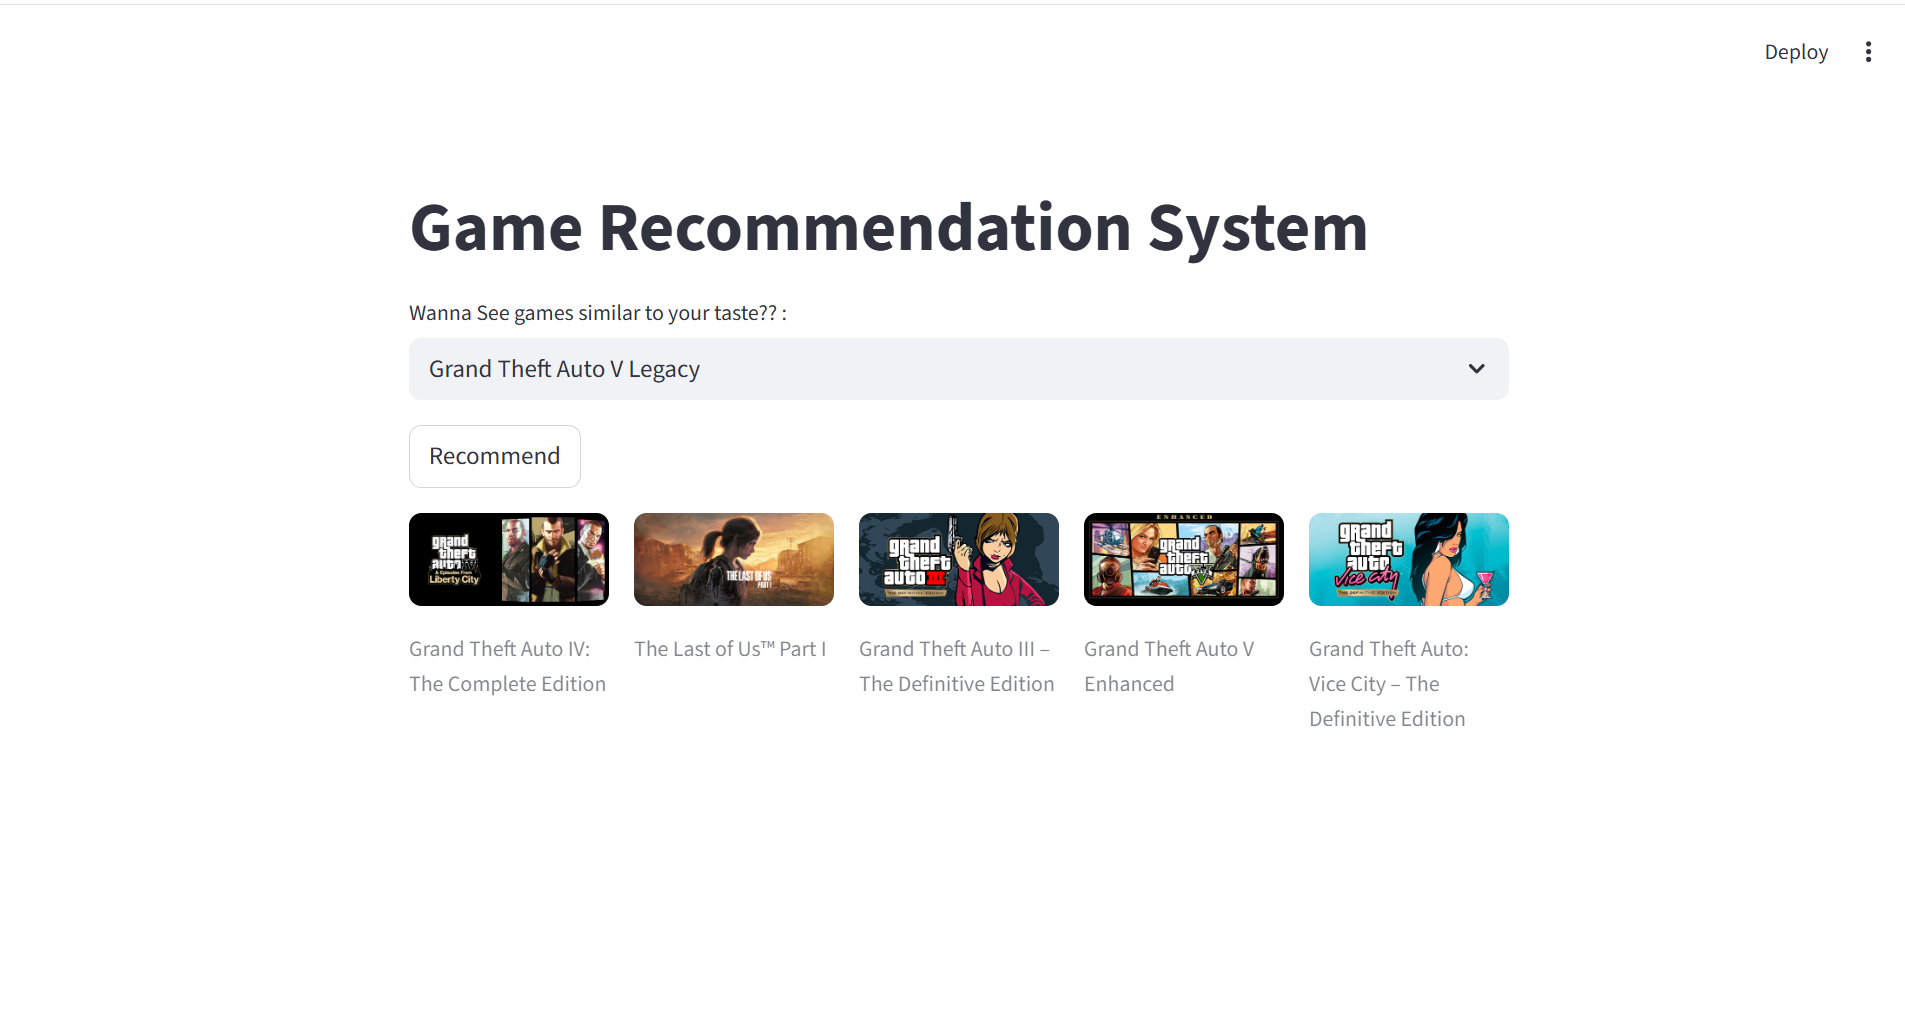